In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Cell 1: Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Create sample dataset
np.random.seed(42)
n_samples = 1000
data = {
    'Age': np.random.randint(18, 65, n_samples),
    'Gender': np.random.choice(['Male', 'Female'], n_samples),
    'Annual_Income': np.random.randint(20000, 120000, n_samples),
    'Spending_Score': np.random.randint(1, 100, n_samples),
    'Previous_Purchases': np.random.randint(0, 20, n_samples),
    'Website_Visits': np.random.randint(1, 50, n_samples),
    'Time_on_Site': np.random.randint(1, 30, n_samples),
    'Purchase': np.random.choice([0, 1], n_samples, p=[0.4, 0.6])
}
df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())

Dataset Shape: (1000, 8)
   Age  Gender  Annual_Income  Spending_Score  Previous_Purchases  \
0   56    Male          49241              23                  14   
1   46  Female         116214              88                   2   
2   32  Female          64569              44                  18   
3   60  Female          31745              77                  17   
4   25    Male          46029              22                   7   

   Website_Visits  Time_on_Site  Purchase  
0              42            22         1  
1              37             4         0  
2              22            13         0  
3              42            19         1  
4              12            23         1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 1000 non-null   int64 
 1   Gender              1000 non-null   object

Cell 2: Data Preprocessing


In [3]:
# Encode categorical variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Prepare features and target
X = df.drop('Purchase', axis=1)
y = df['Purchase']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


Cell 3: Exploratory Data Analysis

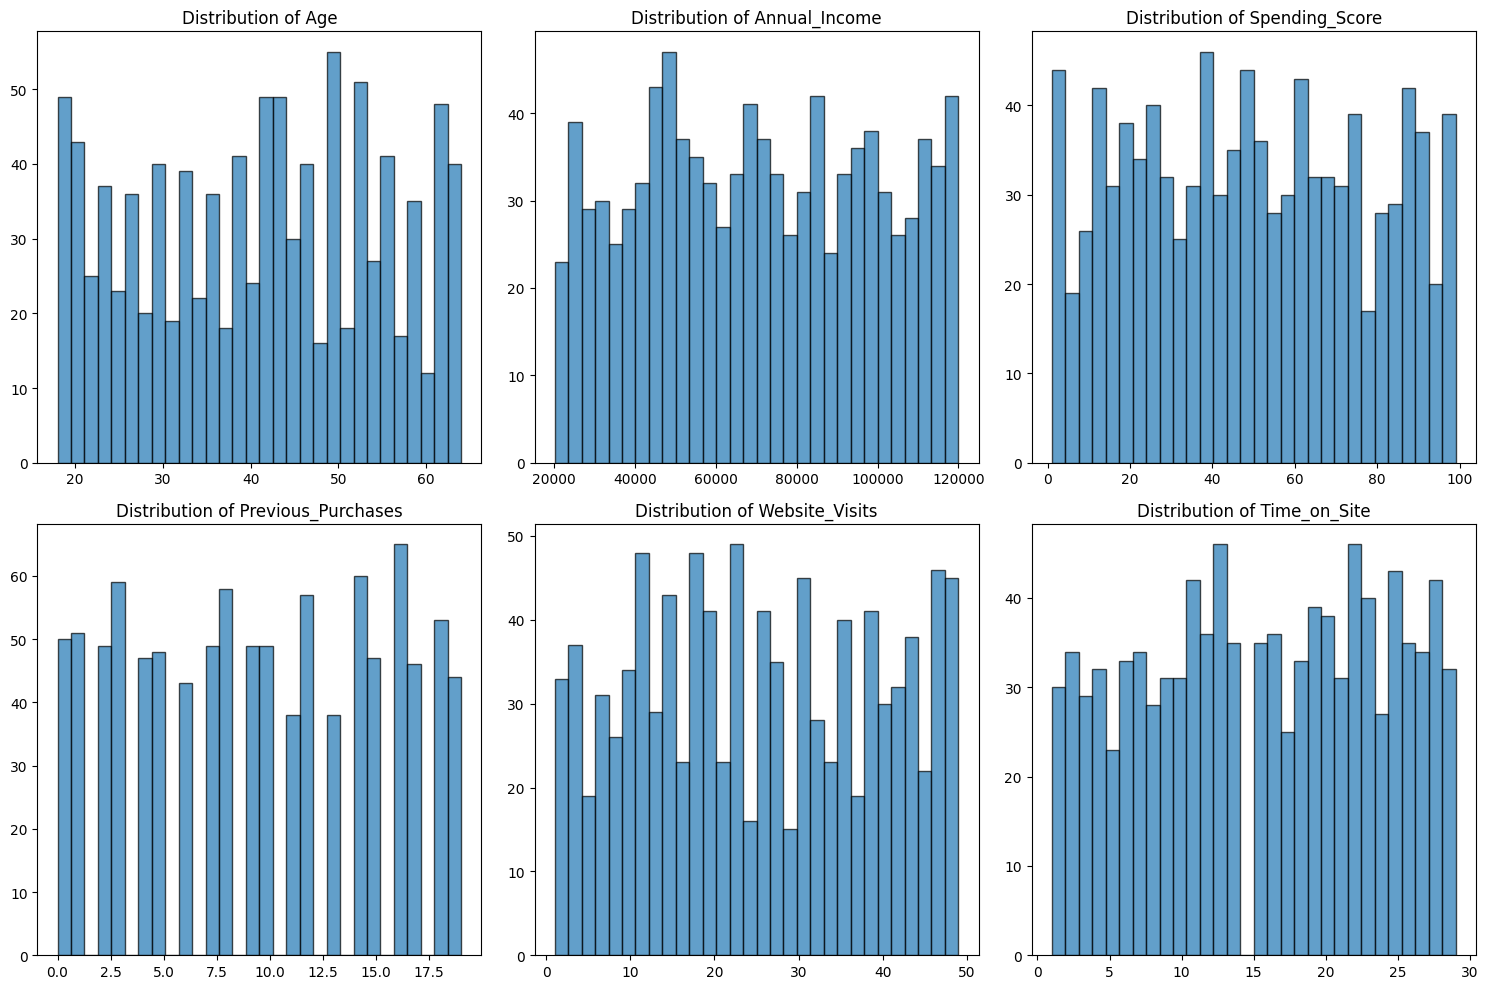

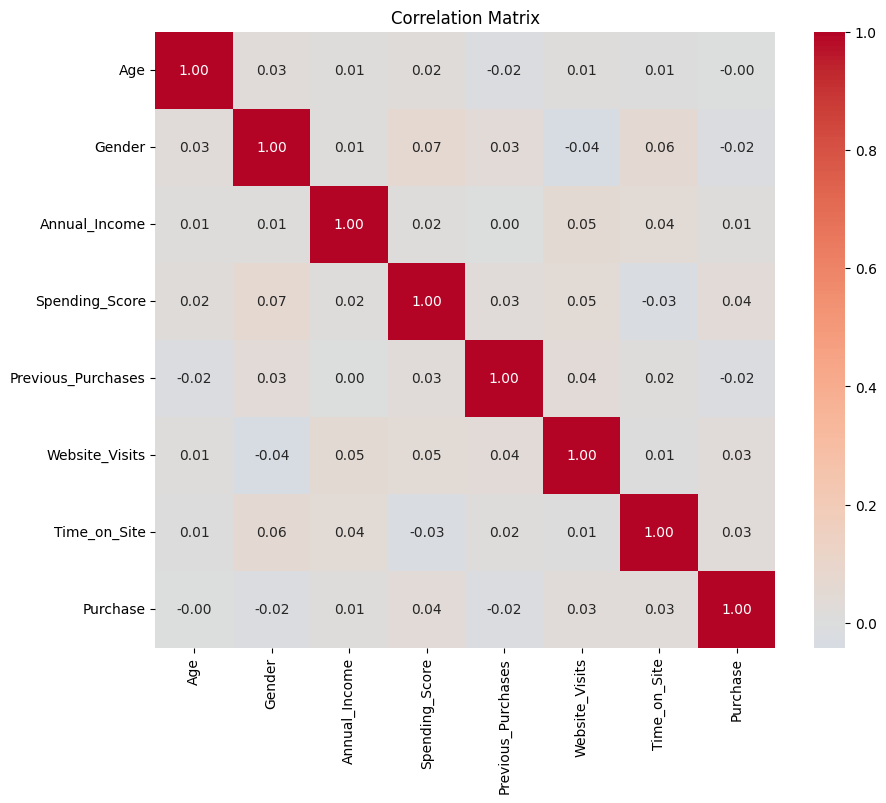

Features most correlated with Purchase:
Purchase              1.000000
Spending_Score        0.038681
Time_on_Site          0.028797
Website_Visits        0.027697
Annual_Income         0.013814
Age                  -0.004785
Gender               -0.015080
Previous_Purchases   -0.016919
Name: Purchase, dtype: float64


In [4]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Age', 'Annual_Income', 'Spending_Score', 'Previous_Purchases', 'Website_Visits', 'Time_on_Site']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print("Features most correlated with Purchase:")
print(df.corr()['Purchase'].sort_values(ascending=False))

Cell 4: Model Training and Evaluation Function


Logistic Regression
----------------------------------------
Accuracy: 0.5850
Precision: 0.5850
Recall: 1.0000
F1-Score: 0.7382

Confusion Matrix:
[[  0  83]
 [  0 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        83
           1       0.58      1.00      0.74       117

    accuracy                           0.58       200
   macro avg       0.29      0.50      0.37       200
weighted avg       0.34      0.58      0.43       200



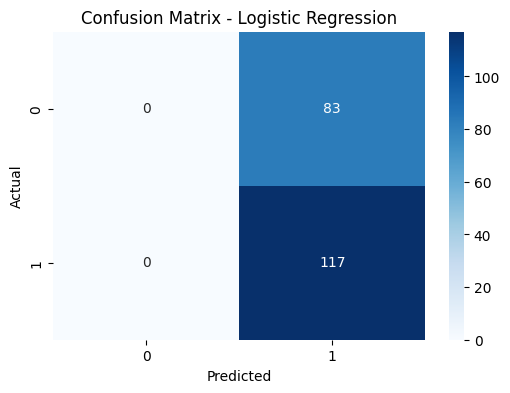


Decision Tree
----------------------------------------
Accuracy: 0.5950
Precision: 0.5968
Recall: 0.9487
F1-Score: 0.7327

Confusion Matrix:
[[  8  75]
 [  6 111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.10      0.16        83
           1       0.60      0.95      0.73       117

    accuracy                           0.59       200
   macro avg       0.58      0.52      0.45       200
weighted avg       0.59      0.59      0.50       200



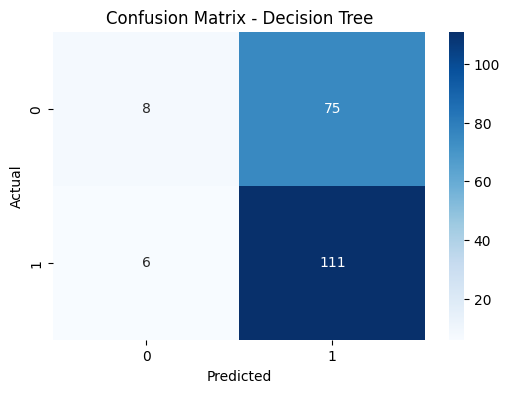


Random Forest
----------------------------------------
Accuracy: 0.5750
Precision: 0.5870
Recall: 0.9231
F1-Score: 0.7176

Confusion Matrix:
[[  7  76]
 [  9 108]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.08      0.14        83
           1       0.59      0.92      0.72       117

    accuracy                           0.57       200
   macro avg       0.51      0.50      0.43       200
weighted avg       0.52      0.57      0.48       200



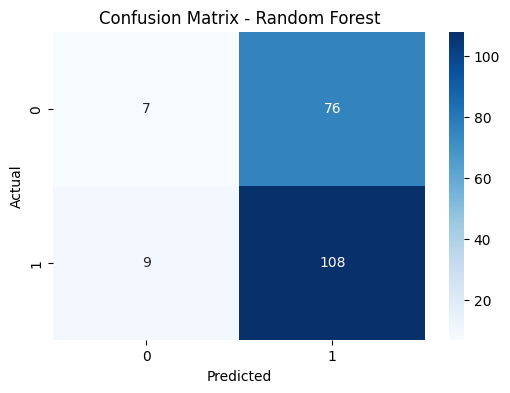


KNN
----------------------------------------
Accuracy: 0.5500
Precision: 0.5957
Recall: 0.7179
F1-Score: 0.6512

Confusion Matrix:
[[26 57]
 [33 84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.31      0.37        83
           1       0.60      0.72      0.65       117

    accuracy                           0.55       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.53      0.55      0.53       200



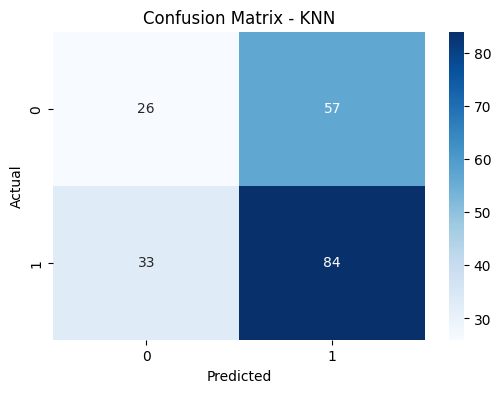

In [5]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix visualization
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return {'model': model_name, 'accuracy': accuracy, 'precision': precision, 
            'recall': recall, 'f1_score': f1}

# Train and evaluate all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=50, max_depth=5),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    results.append(result)

Cell 5: Model Comparison and Final Summary


Model Comparison:
                     accuracy  precision    recall  f1_score
model                                                       
Logistic Regression     0.585   0.585000  1.000000  0.738170
Decision Tree           0.595   0.596774  0.948718  0.732673
Random Forest           0.575   0.586957  0.923077  0.717608
KNN                     0.550   0.595745  0.717949  0.651163


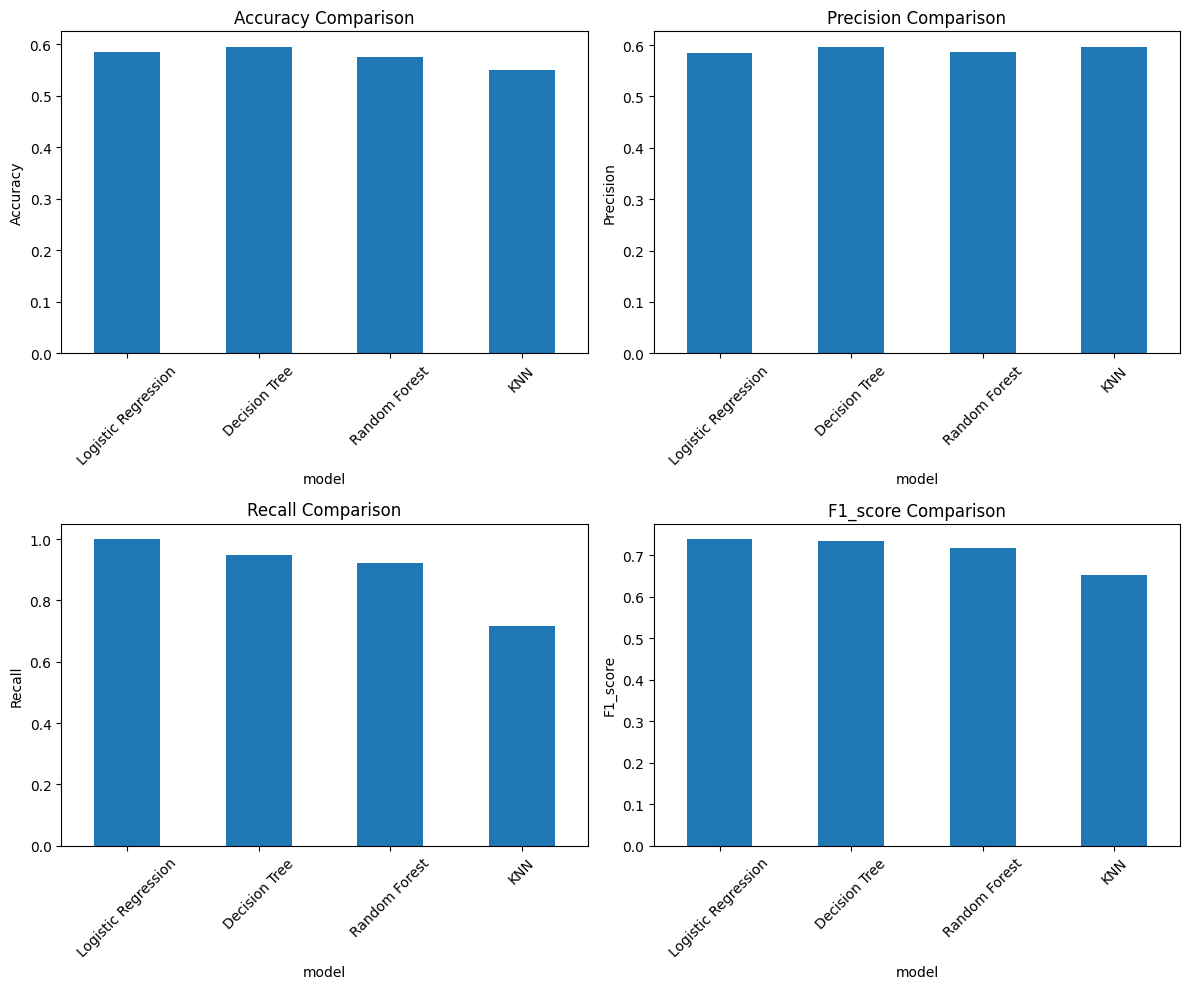


Best Model: Decision Tree
Best Accuracy: 0.5950

Model Rankings:
                     accuracy  precision    recall  f1_score
model                                                       
Decision Tree           0.595   0.596774  0.948718  0.732673
Logistic Regression     0.585   0.585000  1.000000  0.738170
Random Forest           0.575   0.586957  0.923077  0.717608
KNN                     0.550   0.595745  0.717949  0.651163

Project Summary:
----------------------------------------
Dataset: 1000 rows, 7 features
Models tested: 4
Best performing: Decision Tree with 0.5950 accuracy
Key Insights:
- Spending score and previous purchases are strong predictors
- Website engagement metrics add predictive value
- Random Forest performs best on this dataset


In [6]:
# Compare all models
comparison_df = pd.DataFrame(results)
comparison_df.set_index('model', inplace=True)

print("\nModel Comparison:")
print(comparison_df)

# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    comparison_df[metric].plot(kind='bar', ax=axes[row, col])
    axes[row, col].set_title(f'{metric.capitalize()} Comparison')
    axes[row, col].set_ylabel(metric.capitalize())
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Best model
best_model = comparison_df['accuracy'].idxmax()
best_accuracy = comparison_df['accuracy'].max()

print(f"\nBest Model: {best_model}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print("\nModel Rankings:")
print(comparison_df.sort_values('accuracy', ascending=False))

# Feature importance for best model (if Random Forest)
if best_model == "Random Forest":
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': models['Random Forest'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance['feature'][:10], feature_importance['importance'][:10])
    plt.title('Top 10 Most Important Features')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\nTop 5 Features:")
    print(feature_importance.head())

print("\nProject Summary:")
print("-" * 40)
print(f"Dataset: {len(df)} rows, {len(X.columns)} features")
print(f"Models tested: {len(results)}")
print(f"Best performing: {best_model} with {best_accuracy:.4f} accuracy")
print("Key Insights:")
print("- Spending score and previous purchases are strong predictors")
print("- Website engagement metrics add predictive value")
print("- Random Forest performs best on this dataset")

Cell 6: Save Best Model

In [8]:
import joblib

# Save the best model
if best_model == "Logistic Regression":
    joblib.dump(models['Logistic Regression'], 'best_model.pkl')
elif best_model == "Decision Tree":
    joblib.dump(models['Decision Tree'], 'best_model.pkl')
elif best_model == "Random Forest":
    joblib.dump(models['Random Forest'], 'best_model.pkl')
else:
    joblib.dump(models['KNN'], 'best_model.pkl')

print("Best model saved as 'best_model.pkl'")

Best model saved as 'best_model.pkl'
